In [8]:
import pandas as pd

# Online Retail Sales Analysis

## Business Objective

This project analyzes online retail transactions to identify revenue trends, customer behavior, product performance, and return patterns that can support business decision-making.

In [9]:
df = pd.read_csv("../data/OnlineRetail.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1. Load Dataset

The dataset contains online retail transactions including invoice number, product, quantity, price, customer ID, country, and invoice date.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


# 2. Data Understanding

In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

###  Initial Observation

The dataset contains over 500k transaction rows. `InvoiceDate` is currently stored as text and needs conversion to datetime. `CustomerID` also contains missing values, which affects customer-level analysis.

### 3. Data Cleaning & Feature Engineering

In [12]:
df.duplicated().sum()

np.int64(5268)

## Data Quality Check

Before analysis, duplicate transactions are investigated because they can inflate sales and revenue metrics.

In [13]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Numerical Summary

This step provides an overview of numerical fields such as Quantity and UnitPrice and helps identify unusual values.

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## Date Conversion

InvoiceDate is converted to datetime format to enable time-based analysis such as monthly revenue trends.

In [15]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

## Revenue Calculation

Revenue is calculated as Quantity multiplied by UnitPrice. This metric will be used throughout the analysis.

In [16]:
df["Month"] = df["InvoiceDate"].dt.month

## Month Extraction

The month is extracted from InvoiceDate to support monthly sales and revenue analysis.

## 4.  Product Analysis

This section identifies the most popular and highest revenue-generating products in the business.

In [17]:
df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64

### Insight

These products generated the highest sales volume. High sales volume indicates strong customer demand and can help guide inventory planning decisions.

In [18]:
df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

### Insight

Top revenue-generating products are not always the same as top-selling products by quantity. Revenue analysis helps identify products with the greatest financial impact on the business.

# 5. Country Analysis

This section examines the geographic distribution of revenue to identify the most valuable markets.

In [19]:
df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

### Insight

The top countries contribute a disproportionate share of total revenue. Understanding geographic revenue concentration can help the business prioritize its strongest markets.

In [20]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

### Insight

Countries with the highest transaction counts are not always the same countries generating the highest revenue. Both metrics are important for understanding market performance.

6. Customer Analysis

In [21]:
customer_df = df.dropna(subset=["CustomerID"])

# 6. Customer Analysis

This section identifies the most valuable and most active customers based on spending and transaction activity.

In [22]:
customer_df = df.dropna(subset=["CustomerID"])

In [23]:
customer_df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: Revenue, dtype: float64

### Insight

Revenue is concentrated among a small number of high-value customers. Retaining these customers could have a significant impact on overall business performance.

In [24]:
customer_df["CustomerID"].value_counts().head(10)

CustomerID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
15311.0    2491
14646.0    2085
13089.0    1857
13263.0    1677
14298.0    1640
Name: count, dtype: int64

### Insight

The most active customers are not necessarily the highest spending customers. Both frequency and monetary value should be considered when evaluating customer importance.

In [25]:
customer_df.groupby("CustomerID")["Revenue"].mean().sort_values(ascending=False).head(10)

CustomerID
15195.0    3861.000000
13135.0    3096.000000
17846.0    2033.100000
16532.0    1687.200000
15749.0    1435.726667
16000.0    1377.077778
16754.0    1001.200000
12798.0     872.130000
17553.0     743.800000
17949.0     667.732152
Name: Revenue, dtype: float64

### Insight

Some customers place fewer orders but have significantly higher average order values, making them strategically important despite lower transaction frequency.

# 7. Returns Analysis

This section investigates returned and cancelled transactions to identify products that may be contributing to revenue leakage.

In [26]:
returns_df = df[df["Quantity"] < 0]

In [27]:
returns_df.shape

(10624, 10)

### Insight

Returned transactions represent revenue that was reversed. Understanding return volume is important because returns directly reduce profitability.

In [28]:
returns_df.groupby("Description")["Quantity"].sum().sort_values().head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
printing smudges/thrown away          -19200
Unsaleable, destroyed.                -15644
check                                 -13247
?                                      -9496
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
Printing smudges/thrown away           -9058
Damaged                                -7540
throw away                             -5368
Name: Quantity, dtype: int64

### Insight

Products with the highest return volumes should be investigated for potential quality issues, inaccurate descriptions, or customer dissatisfaction.

In [29]:
returns_df["Revenue"].sum()

np.float64(-896812.49)

### Insight

Returns represent a direct reduction in revenue. Monitoring return-related revenue loss can help quantify the financial impact of customer refunds and cancellations.

# 8. Data Visualization

This section visualizes key business metrics to make trends and patterns easier to interpret.

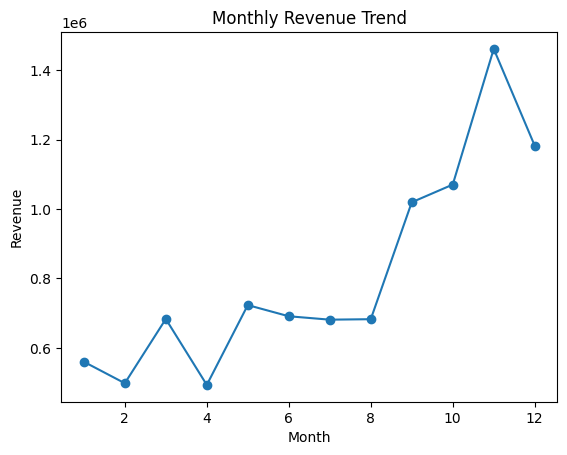

In [36]:
import matplotlib.pyplot as plt

monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

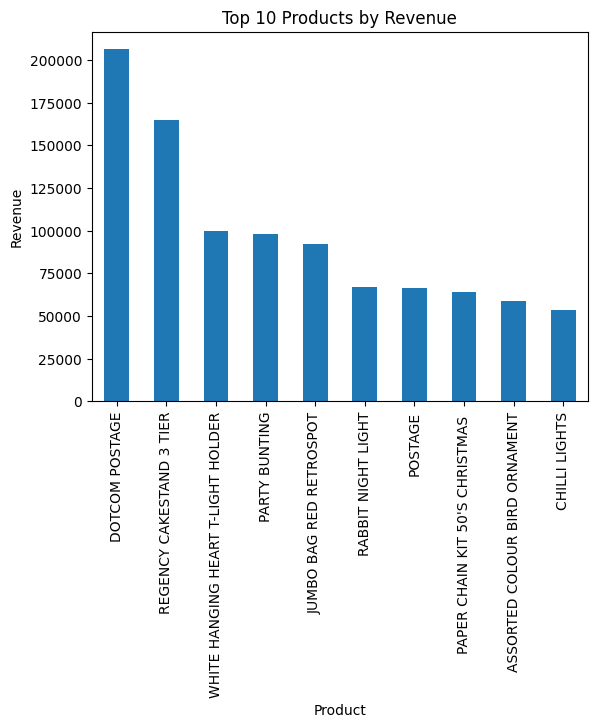

In [37]:
import matplotlib.pyplot as plt

top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

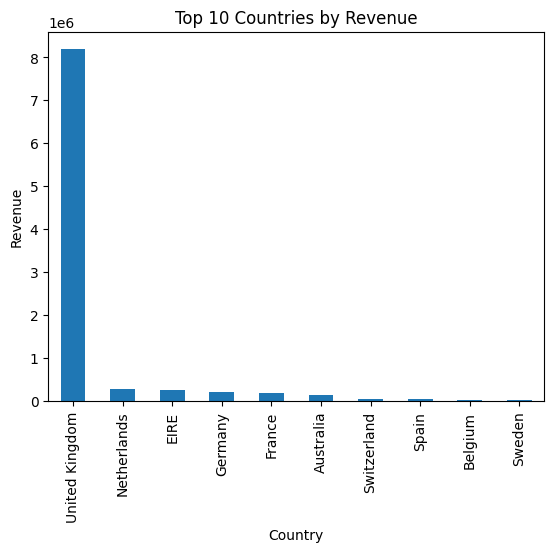

In [38]:
import matplotlib.pyplot as plt

top_countries = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

# 9. Executive Summary

## Key Findings

### Revenue Performance
- Revenue peaked in November, indicating strong seasonal demand during the holiday shopping period.
- Q4 generated significantly higher revenue than earlier months.

### Product Performance
- Several products dominated sales volume.
- Top-selling products by quantity were not always the highest revenue-generating products.

### Customer Insights
- Revenue was concentrated among a relatively small number of high-value customers.
- The most active customers were not always the highest spending customers.

### Geographic Insights
- Revenue was concentrated in a small number of countries.
- The United Kingdom represented the strongest market in both transaction volume and revenue generation.

### Returns Analysis
- Returned and cancelled transactions reduced total revenue.
- Certain products experienced disproportionately high return volumes and should be investigated further.

---

## Business Recommendations

1. Increase inventory levels ahead of Q4 demand peaks.
2. Develop retention strategies for high-value customers.
3. Investigate products with high return volumes.
4. Focus marketing investment on top-performing geographic markets.
5. Monitor customer purchasing behavior to identify VIP customers and growth opportunities.

## 9. RFM Customer Segmentation

RFM analysis is used to group customers based on how recently they purchased, how often they purchased, and how much they spent. This helps the business identify high-value customers and customers who may need retention campaigns.

In [ ]:
customer_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].dropna(subset=['CustomerID']).copy()
analysis_date = customer_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = customer_sales.groupby('CustomerID').agg(
    LastPurchaseDate=('InvoiceDate', 'max'),
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm.head()

In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

def assign_segment(row):
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['M_Score'] >= 4 and row['R_Score'] <= 2:
        return 'High Value At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'At Risk'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New or Recent Customers'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
rfm.head()

In [ ]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Average_Recency=('Recency', 'mean'),
    Average_Frequency=('Frequency', 'mean'),
    Average_Spend=('Monetary', 'mean')
).sort_values('Total_Revenue', ascending=False)

segment_summary

### RFM Insight

RFM segmentation shows which customers are most valuable and which customers may need retention attention. Champions and loyal customers should be prioritized because they buy recently, frequently, and generate strong revenue. At-risk customers may need reactivation campaigns.

## 10. Cohort Retention Analysis

Cohort analysis groups customers by the month of their first purchase and tracks how many return in later months. This helps measure customer retention over time.

In [ ]:
cohort_df = customer_sales[['CustomerID', 'InvoiceNo', 'InvoiceDate']].drop_duplicates().copy()
cohort_df['InvoiceMonth'] = cohort_df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
cohort_df['CohortMonth'] = cohort_df.groupby('CustomerID')['InvoiceMonth'].transform('min')

cohort_df['CohortIndex'] = (
    (cohort_df['InvoiceMonth'].dt.year - cohort_df['CohortMonth'].dt.year) * 12
    + (cohort_df['InvoiceMonth'].dt.month - cohort_df['CohortMonth'].dt.month)
    + 1
)

cohort_counts = cohort_df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts.head()

In [ ]:
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0).round(3) * 100
retention

### Cohort Insight

The cohort table shows customer retention after the first purchase month. If retention drops quickly after month one, the business may need better follow-up campaigns, loyalty offers, or product recommendations to encourage repeat purchases.